# Lecture des fichiers

In [1]:
from pathlib import Path
import pandas as pd

import os
import duckdb

# Lister tous les fichiers Parquet dans le dossier data/duck_db
parquet_dir = '../data/bronze'
parquet_files = sorted([os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir)])


In [2]:
parquet_files

['../data/bronze/2019-Dec.parquet',
 '../data/bronze/2019-Nov.parquet',
 '../data/bronze/2019-Oct.parquet',
 '../data/bronze/2020-Apr.parquet',
 '../data/bronze/2020-Feb.parquet',
 '../data/bronze/2020-Jan.parquet',
 '../data/bronze/2020-Mar.parquet']

In [3]:

# Connexion à une base DuckDB (fichier ou en mémoire)
con = duckdb.connect(database='amazing.duckdb')  # ou 'ma_base.duckdb' pour un fichier persistant


## Nombre total d'entrées

In [4]:
# Afficher le nombre total de lignes dans tous les fichiers Parquet via DuckDB
if parquet_files:
    total_rows_duckdb = con.execute(
        "SELECT SUM(row_count) FROM (" +
        " UNION ALL ".join(
            [f"SELECT COUNT(*) AS row_count FROM parquet_scan('{str(f)}')" for f in parquet_files]
        ) +
        ")"
    ).fetchone()[0]
    print(f"Nombre total de lignes dans les fichiers Parquet (via DuckDB) : {total_rows_duckdb}")
else:
    print("Aucun fichier Parquet trouvé.")

Nombre total de lignes dans les fichiers Parquet (via DuckDB) : 411709736


## Lecture de tous les fichiers

In [5]:
# Lire et concaténer toutes les données Parquet du dossier bronze via DuckDB
# Ajout d'un paramètre pour définir dynamiquement la limite
limit = 10000  # Modifiez cette valeur selon vos besoins

if parquet_files:
    query = " UNION ALL ".join([f"SELECT * FROM parquet_scan('{str(f)}')" for f in parquet_files])
    if limit is not None:
        query = f"SELECT * FROM ({query}) LIMIT {limit}"
    df_all = con.execute(query).df()
    print(f"Nombre total de lignes lues : {len(df_all)}")
    display(df_all.head())
else:
    print("Aucun fichier Parquet trouvé dans le dossier bronze.")

Nombre total de lignes lues : 10000


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,556695836,ca5eefc5-11f9-450c-91ed-380285a0bc80
1,2019-12-01 00:00:00 UTC,view,22700068,2232732091643068746,,force,102.96,577702456,de33debe-c7bf-44e8-8a12-3bf8421f842a
2,2019-12-01 00:00:01 UTC,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,539453785,5ee185a7-0689-4a33-923d-ba0130929a76
3,2019-12-01 00:00:02 UTC,purchase,26400248,2053013553056579841,computers.peripherals.printer,,132.31,535135317,61792a26-672f-4e61-9832-7b63bb1714db
4,2019-12-01 00:00:02 UTC,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,517987650,906c6ca8-ff5c-419a-bde9-967ba8e2233e


In [6]:
df_all.shape

(10000, 9)

## Lecture du premier fichier

In [7]:

# Exemple : lire le même fichier Parquet que précédemment via DuckDB
if parquet_files:
    parquet_path = str(parquet_files[0])
    print(f"Lecture via DuckDB : {parquet_path}")
    df_duck = con.execute(f"SELECT * FROM parquet_scan('{parquet_path}') LIMIT 10000").df()
    display(df_duck.head(2000))
else:
    print("Aucun fichier Parquet à lire avec DuckDB.")

Lecture via DuckDB : ../data/bronze/2019-Dec.parquet


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,556695836,ca5eefc5-11f9-450c-91ed-380285a0bc80
1,2019-12-01 00:00:00 UTC,view,22700068,2232732091643068746,,force,102.96,577702456,de33debe-c7bf-44e8-8a12-3bf8421f842a
2,2019-12-01 00:00:01 UTC,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,539453785,5ee185a7-0689-4a33-923d-ba0130929a76
3,2019-12-01 00:00:02 UTC,purchase,26400248,2053013553056579841,computers.peripherals.printer,,132.31,535135317,61792a26-672f-4e61-9832-7b63bb1714db
4,2019-12-01 00:00:02 UTC,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,517987650,906c6ca8-ff5c-419a-bde9-967ba8e2233e
...,...,...,...,...,...,...,...,...,...
1995,2019-12-01 00:12:57 UTC,view,26800077,2232732066611463064,,startline,342.09,543419105,bddd8ae8-4bec-417d-be2b-16e064a2f200
1996,2019-12-01 00:12:57 UTC,view,1004853,2232732093077520756,construction.tools.light,meizu,205.67,579969911,9585c706-c331-49bb-9558-d4c17b3eeb93
1997,2019-12-01 00:12:58 UTC,view,1005217,2232732093077520756,construction.tools.light,xiaomi,137.22,572416803,47a57b70-ef54-4276-aa59-4f547ce100bd
1998,2019-12-01 00:13:01 UTC,view,8400241,2232732105014510203,apparel.sock,bumbleride,93.26,571254910,db0eb874-6727-45d6-a4a9-6d5750b6e520


In [8]:
# Afficher le nombre total de lignes du fichier Parquet sans LIMIT
if parquet_files:
    parquet_path = str(parquet_files[0])
    total_rows_full = con.execute(f"SELECT COUNT(*) FROM parquet_scan('{parquet_path}')").fetchone()[0]
    print(f"Nombre total de lignes dans le fichier Parquet sans LIMIT : {total_rows_full}")
else:
    print("Aucun fichier Parquet trouvé.")

Nombre total de lignes dans le fichier Parquet sans LIMIT : 67542878


In [9]:
# Copier le résultat DuckDB dans un DataFrame pandas nommé df
if 'df_all' in locals():
    df = df_all.copy()
    print("Le DataFrame df est prêt pour l'analyse.")
    df
else:
    print("Aucun résultat DuckDB à copier dans df.")

df


Le DataFrame df est prêt pour l'analyse.


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,556695836,ca5eefc5-11f9-450c-91ed-380285a0bc80
1,2019-12-01 00:00:00 UTC,view,22700068,2232732091643068746,,force,102.96,577702456,de33debe-c7bf-44e8-8a12-3bf8421f842a
2,2019-12-01 00:00:01 UTC,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,539453785,5ee185a7-0689-4a33-923d-ba0130929a76
3,2019-12-01 00:00:02 UTC,purchase,26400248,2053013553056579841,computers.peripherals.printer,,132.31,535135317,61792a26-672f-4e61-9832-7b63bb1714db
4,2019-12-01 00:00:02 UTC,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,517987650,906c6ca8-ff5c-419a-bde9-967ba8e2233e
...,...,...,...,...,...,...,...,...,...
9995,2019-12-01 00:57:35 UTC,view,1004958,2232732093077520756,construction.tools.light,xiaomi,323.30,532569409,43777de4-313f-4f0d-a6a7-1bbab6f6fd20
9996,2019-12-01 00:57:35 UTC,view,100010605,2232732116137804674,apparel.underwear,dolcevita,174.26,514567336,41960d57-ea88-4c83-873c-cdc2e8e27e85
9997,2019-12-01 00:57:35 UTC,view,15700036,2232732094134485388,,,99.10,531655488,c062320e-2fb8-4028-8bdf-9e501ee2ec97
9998,2019-12-01 00:57:35 UTC,view,44300009,2053013552469377249,apparel.jeans,,35.26,558392392,dafa84e0-4939-4307-91c9-ae151baf4755


In [10]:
import hashlib
print(df.columns.tolist())

def hash_value(val):
    return hashlib.sha256(str(val).encode()).hexdigest()

# Pseudonymiser les colonnes sensibles
df['user_id_pseudo'] = df['user_id'].apply(hash_value)
df['user_session_pseudo'] = df['user_session'].apply(hash_value)

# (Optionnel) Supprimer les colonnes originales
df = df.drop(['user_id', 'user_session'], axis=1)
print(df.columns.tolist())
df


['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id_pseudo', 'user_session_pseudo']


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id_pseudo,user_session_pseudo
0,2019-12-01 00:00:00 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,18979219d5fd71c19601d83aa630816897f8ef3352e632...,19059adb93d90eaea968718e9ce4390d71afeb85a783e2...
1,2019-12-01 00:00:00 UTC,view,22700068,2232732091643068746,,force,102.96,33cab333bf6f83163cd180b2d67b3a09b936953b8f60c9...,c74a5e9903cefbd0a282f61358352324eb63453584f890...
2,2019-12-01 00:00:01 UTC,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,9bc238f33b5df631f006fb9a617f6a9f347be96e342b1c...,370a00c2b0703ce5bd6b653e1f7ad01e2b4d69bfb38588...
3,2019-12-01 00:00:02 UTC,purchase,26400248,2053013553056579841,computers.peripherals.printer,,132.31,03221e64fbe5c20d0b7386ee043591b862dbe2d3d43d4b...,2a1a147eb6944f669f1edcfadff47cf0951eb23206c541...
4,2019-12-01 00:00:02 UTC,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,b5e969b93666a37422b675968368fcc033faecd61ac2ff...,2daf3be73e3486aad65a1617e406c75bee85012402cccf...
...,...,...,...,...,...,...,...,...,...
9995,2019-12-01 00:57:35 UTC,view,1004958,2232732093077520756,construction.tools.light,xiaomi,323.30,1d64e9e60fbcc9d15dffad59313cd92fecec798f2b823e...,79ede86b9579cebddd775183a24545d49d181e2623e379...
9996,2019-12-01 00:57:35 UTC,view,100010605,2232732116137804674,apparel.underwear,dolcevita,174.26,6df214d02e7c89d65dc8e356b774f2490666d0495cd27f...,3a7dd2cd9c4fc438bafcacaadaa8eeec076c8d0a790197...
9997,2019-12-01 00:57:35 UTC,view,15700036,2232732094134485388,,,99.10,d34b9969cee1228cfdd7ef150b7577358164693c1f213c...,ee8b823eca18efd0f0d39234c4a8afda591752eec04d3b...
9998,2019-12-01 00:57:35 UTC,view,44300009,2053013552469377249,apparel.jeans,,35.26,ef5a26f0f77465f739716cd155c617b658c58067676ec1...,f93c4ece21e10a4c48bf9a5f35c313a0e6f1d499a6b7e6...


In [11]:
# Comprendre la structure des données
print("Aperçu du DataFrame :")
display(df.head())

print("\nTypes de colonnes :")
print(df.dtypes)

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

print("\nNombre de doublons :")
print(df.duplicated().sum())


Aperçu du DataFrame :


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id_pseudo,user_session_pseudo
0,2019-12-01 00:00:00 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,18979219d5fd71c19601d83aa630816897f8ef3352e632...,19059adb93d90eaea968718e9ce4390d71afeb85a783e2...
1,2019-12-01 00:00:00 UTC,view,22700068,2232732091643068746,,force,102.96,33cab333bf6f83163cd180b2d67b3a09b936953b8f60c9...,c74a5e9903cefbd0a282f61358352324eb63453584f890...
2,2019-12-01 00:00:01 UTC,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,9bc238f33b5df631f006fb9a617f6a9f347be96e342b1c...,370a00c2b0703ce5bd6b653e1f7ad01e2b4d69bfb38588...
3,2019-12-01 00:00:02 UTC,purchase,26400248,2053013553056579841,computers.peripherals.printer,,132.31,03221e64fbe5c20d0b7386ee043591b862dbe2d3d43d4b...,2a1a147eb6944f669f1edcfadff47cf0951eb23206c541...
4,2019-12-01 00:00:02 UTC,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,b5e969b93666a37422b675968368fcc033faecd61ac2ff...,2daf3be73e3486aad65a1617e406c75bee85012402cccf...



Types de colonnes :
event_time              object
event_type              object
product_id               int64
category_id              int64
category_code           object
brand                   object
price                  float64
user_id_pseudo          object
user_session_pseudo     object
dtype: object

Valeurs manquantes par colonne :
event_time             0
event_type             0
product_id             0
category_id            0
category_code          0
brand                  0
price                  0
user_id_pseudo         0
user_session_pseudo    0
dtype: int64

Nombre de doublons :
2


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   event_time           10000 non-null  object 
 1   event_type           10000 non-null  object 
 2   product_id           10000 non-null  int64  
 3   category_id          10000 non-null  int64  
 4   category_code        10000 non-null  object 
 5   brand                10000 non-null  object 
 6   price                10000 non-null  float64
 7   user_id_pseudo       10000 non-null  object 
 8   user_session_pseudo  10000 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


# Visualisation des valeurs manquante

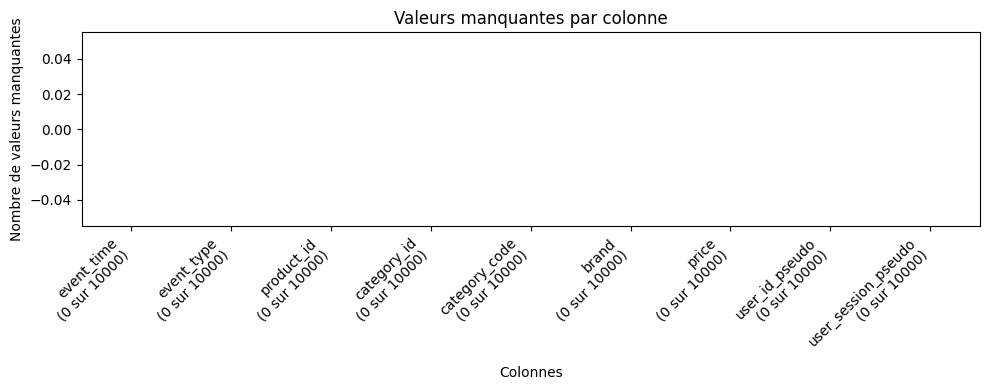

In [13]:
import matplotlib.pyplot as plt

total_rows = len(df)
missing_values = df.isnull().sum()
labels = [f"{col}\n({missing} sur {total_rows})" for col, missing in missing_values.items()]

ax = missing_values.plot(kind='bar', figsize=(10, 4))
ax.set_title('Valeurs manquantes par colonne')
ax.set_ylabel('Nombre de valeurs manquantes')
ax.set_xlabel('Colonnes')
ax.set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Suppression des doublons

In [14]:
# Supprimer les doublons du DataFrame df
df = df.drop_duplicates()
print(f"Nombre de lignes après suppression des doublons : {len(df)}")
df

Nombre de lignes après suppression des doublons : 9998


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id_pseudo,user_session_pseudo
0,2019-12-01 00:00:00 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,18979219d5fd71c19601d83aa630816897f8ef3352e632...,19059adb93d90eaea968718e9ce4390d71afeb85a783e2...
1,2019-12-01 00:00:00 UTC,view,22700068,2232732091643068746,,force,102.96,33cab333bf6f83163cd180b2d67b3a09b936953b8f60c9...,c74a5e9903cefbd0a282f61358352324eb63453584f890...
2,2019-12-01 00:00:01 UTC,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,9bc238f33b5df631f006fb9a617f6a9f347be96e342b1c...,370a00c2b0703ce5bd6b653e1f7ad01e2b4d69bfb38588...
3,2019-12-01 00:00:02 UTC,purchase,26400248,2053013553056579841,computers.peripherals.printer,,132.31,03221e64fbe5c20d0b7386ee043591b862dbe2d3d43d4b...,2a1a147eb6944f669f1edcfadff47cf0951eb23206c541...
4,2019-12-01 00:00:02 UTC,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,b5e969b93666a37422b675968368fcc033faecd61ac2ff...,2daf3be73e3486aad65a1617e406c75bee85012402cccf...
...,...,...,...,...,...,...,...,...,...
9995,2019-12-01 00:57:35 UTC,view,1004958,2232732093077520756,construction.tools.light,xiaomi,323.30,1d64e9e60fbcc9d15dffad59313cd92fecec798f2b823e...,79ede86b9579cebddd775183a24545d49d181e2623e379...
9996,2019-12-01 00:57:35 UTC,view,100010605,2232732116137804674,apparel.underwear,dolcevita,174.26,6df214d02e7c89d65dc8e356b774f2490666d0495cd27f...,3a7dd2cd9c4fc438bafcacaadaa8eeec076c8d0a790197...
9997,2019-12-01 00:57:35 UTC,view,15700036,2232732094134485388,,,99.10,d34b9969cee1228cfdd7ef150b7577358164693c1f213c...,ee8b823eca18efd0f0d39234c4a8afda591752eec04d3b...
9998,2019-12-01 00:57:35 UTC,view,44300009,2053013552469377249,apparel.jeans,,35.26,ef5a26f0f77465f739716cd155c617b658c58067676ec1...,f93c4ece21e10a4c48bf9a5f35c313a0e6f1d499a6b7e6...


# Déduction des catégories code en 
# fonction des catégorie id

#Déduire le category_code à partir de category_id
#Création d'un dictionnaire d'association unique
catid_to_code = df.dropna(subset=['category_id', 'category_code']).drop_duplicates('category_id')[['category_id', 'category_code']].set_index('category_id')['category_code'].to_dict()

#Fonction de mapping
def infer_category_code(cat_id):
    return catid_to_code.get(cat_id, None)

#Création d'une nouvelle colonne avec le code déduit
df['category_code_inferred'] = df['category_id'].apply(infer_category_code)

#Vérification rapide
print(df[['category_id', 'category_code', 'category_code_inferred']].head(10))

In [15]:

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
event_time             0
event_type             0
product_id             0
category_id            0
category_code          0
brand                  0
price                  0
user_id_pseudo         0
user_session_pseudo    0
dtype: int64


# Déduction des brands en 
# fonction des catégorie id

#Déduire le brand à partir de category_id
#Création d'un dictionnaire d'association unique
catid_to_brand = df.dropna(subset=['category_id', 'brand']).drop_duplicates('category_id')[['category_id', 'brand']].set_index('category_id')['brand'].to_dict()

#Fonction de mapping
def infer_brand(cat_id):
    return catid_to_brand.get(cat_id, None)

#Création d'une nouvelle colonne avec le brand déduit
df['brand_inferred'] = df['category_id'].apply(infer_brand)

#Vérification rapide
print(df[['category_id', 'brand', 'brand_inferred']].head(10))

In [16]:
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
event_time             0
event_type             0
product_id             0
category_id            0
category_code          0
brand                  0
price                  0
user_id_pseudo         0
user_session_pseudo    0
dtype: int64


## Convertir toutes les colonnes se terminant par '_id' en type string (caractère)

In [17]:

for col in df.columns:
    if col.endswith('_id'):
        df[col] = df[col].astype(str)
df.dtypes

/tmp/ipykernel_87049/1158455358.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str)
/tmp/ipykernel_87049/1158455358.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str)


event_time              object
event_type              object
product_id              object
category_id             object
category_code           object
brand                   object
price                  float64
user_id_pseudo          object
user_session_pseudo     object
dtype: object

In [18]:
df.describe()

,price
count,9998.000000
mean,287.282349
std,363.156577
min,0.000000
25%,61.120000
50%,154.440000
75%,346.790000
max,2574.070000


In [19]:
df.describe(include='object')


,event_time,event_type,product_id,category_id,category_code,brand,user_id_pseudo,user_session_pseudo
count,9998,9998,9998,9998,9998,9998,9998,9998
unique,3285,3,4042,545,122,769,1704,2038
top,2019-12-01 00:54:11 UTC,view,1005115,2232732093077520756,construction.tools.light,samsung,4c9f59db99a20213fd7507969a098ee42e7b49f74db428...,d55d6e65e2591f7706627b1f22026e1982ccfb4978d556...
freq,10,9618,97,2550,2597,1169,147,147


# Outliers

In [20]:
# Détection des outliers sur la colonne 'price' avec la méthode de l'IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df['price'] < (Q1 - 1.5 * IQR)) | (df['price'] > (Q3 + 1.5 * IQR))
outliers = df[outlier_mask]

print(f"Nombre d'outliers détectés sur 'price' : {outliers.shape[0]}")
display(outliers[['price']].describe())
outliers.head()

Nombre d'outliers détectés sur 'price' : 982


,price
count,982.000000
mean,1183.835703
std,412.062710
min,776.340000
25%,912.500000
50%,994.340000
75%,1312.520000
max,2574.070000


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id_pseudo,user_session_pseudo
0,2019-12-01 00:00:00 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,18979219d5fd71c19601d83aa630816897f8ef3352e632...,19059adb93d90eaea968718e9ce4390d71afeb85a783e2...
11,2019-12-01 00:00:04 UTC,view,1004233,2232732093077520756,construction.tools.light,apple,1312.52,eb82c1a224c50225ec297d2dd79a361b5962dfd34bfe8f...,b1daa9c7882e3e3d4ced1b5502c8dedd6ac6c3b2dac7f5...
16,2019-12-01 00:00:07 UTC,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,9877f74fd821e59594300e2b1b83ca16e8a9d07d7ce502...,1dd9257c977ce640eb8ad85a3fda654f7e8cbf58af711c...
20,2019-12-01 00:00:07 UTC,view,1004233,2232732093077520756,construction.tools.light,apple,1312.52,eb82c1a224c50225ec297d2dd79a361b5962dfd34bfe8f...,b1daa9c7882e3e3d4ced1b5502c8dedd6ac6c3b2dac7f5...
21,2019-12-01 00:00:08 UTC,view,1005115,2232732093077520756,construction.tools.light,apple,912.50,086832ec3d55914f627f084d42be60b8bf8a792f09840f...,9a7a61d22b052aba6298c20914975e99cdd305ab76412c...


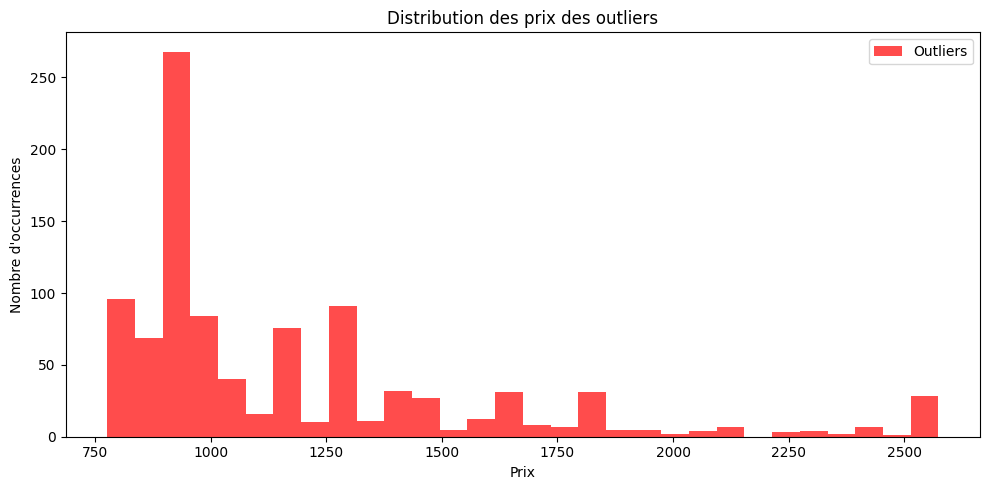

In [21]:
# Visualiser les outliers sur la colonne 'price'
plt.figure(figsize=(10, 5))
plt.hist(outliers['price'], bins=30, color='red', alpha=0.7, label='Outliers')
plt.xlabel('Prix')
plt.ylabel('Nombre d\'occurrences')
plt.title('Distribution des prix des outliers')
plt.legend()
plt.tight_layout()
plt.show()

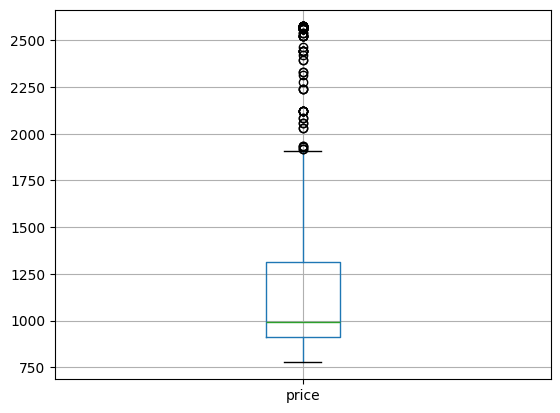

In [22]:
outliers[['price']].boxplot()
plt.show()

In [23]:
# Afficher les catégories de produits dont le prix est supérieur ou égal à 2500
categories_high_price = df[df['price'] >= 2500]['category_code'].unique()
print("Catégories de produits avec un prix >= 2500 :")
print(categories_high_price)

Catégories de produits avec un prix >= 2500 :
['appliances.personal.massager' 'furniture.living_room.sofa'
 'computers.peripherals.printer' 'electronics.video.tv' ''
 'electronics.clocks' 'construction.tools.light' 'computers.notebook'
 'electronics.audio.headphone']
